In [2]:
import numpy as np
import matplotlib.pyplot as plt

### PCA

In [3]:
from sklearn.datasets import load_iris

dataset = load_iris()
X, y = dataset.data, dataset.target

#### manual impl of PCA

In [4]:
# X -> (150, 4)
# cov matrix 4x4
X_centered = X - np.mean(X, axis=0)
n = X.shape[0]
var = (1/n) * np.sum(X_centered**2, axis=0)
cov = (1/n) * X_centered.T @ X_centered
np.allclose(var, np.diag(cov))

True

In [5]:
# cov is symmetric
eigv, eigw = np.linalg.eigh(cov)

# unit vectors ->
print(np.sqrt(np.sum(eigw**2, axis=0)))

sorted_idx = np.argsort(eigv)[::-1]
eigv, eigw = eigv[sorted_idx], eigw[:, sorted_idx]
PC_1, PC_2 = eigw[:, 0], eigw[:, 1]
PC_1

[1. 1. 1. 1.]


array([-0.36138659,  0.08452251, -0.85667061, -0.3582892 ])

the maximizing vector is associated with the largest eigenvalue

In [6]:
var_ratio = eigv/np.sum(eigv)
print(var_ratio)

[0.92461872 0.05306648 0.01710261 0.00521218]


we can preserve ~92.5% of data variance by reducing dimensions to 1

In [7]:
d = 1
components = eigw[:, :d]
components.shape

(4, 1)

transform og data onto the principal component direction
- Z=XW

In [8]:
X_pca = X_centered @ components
X_pca.shape

(150, 1)

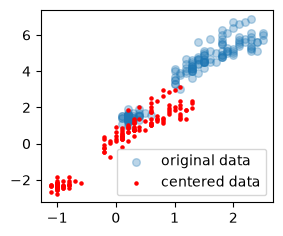

In [18]:
plt.figure(figsize=(3, 2.5))
plt.scatter(X[:, 3], X[:, 2], s=30, alpha=0.3, label='original data')
plt.scatter(X_centered[:, 3], X_centered[:, 2], s=5, c='r', label='centered data')
_ = plt.legend()

[-0.3582892  -0.85667061]


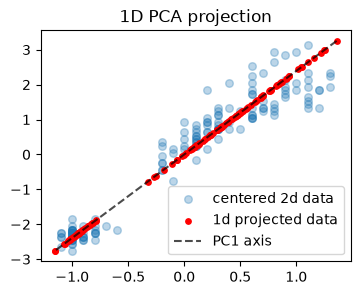

In [10]:
plt.figure(figsize=(4, 3))
plt.scatter(X_centered[:, 3], X_centered[:, 2], s=30, alpha=0.3, label='centered 2d data')

# reconstructing 1d PCA projection back into the original 2d space
# placing the 1d points exactly along the line of the first PC
X_reconstructed = X_pca @ components.T

plt.scatter(X_reconstructed[:, 3], X_reconstructed[:, 2], s=15, color='red', label='1d projected data')

# features 3 and 2
direction_vector = components[[3, 2], 0] 
print(direction_vector)

line_ax = np.linspace(X_pca.min(), X_pca.max(), 100)
plt.plot(line_ax*direction_vector[0], line_ax*direction_vector[1], color='black', linestyle='--', alpha=0.7, label='PC1 axis')

plt.legend()
_ = plt.title("1D PCA projection")

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_pca_train, X_pca_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42, stratify=y)
model = LogisticRegression(max_iter=1000)
model.fit(X_pca_train, y_train)
my_pca_score = model.score(X_pca_test, y_test)
my_pca_score

0.9111111111111111

#### sklearn PCA

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

model = LogisticRegression(max_iter=1000)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# no pca
model.fit(X_train, y_train)
no_pca_score = model.score(X_test, y_test)

# sklearn pca 2d
pca_2d = PCA(n_components=2)
X_train_PCA2d = pca_2d.fit_transform(X_train)
X_test_PCA2d = pca_2d.transform(X_test)
model.fit(X_train_PCA2d, y_train)
pca2d_score = model.score(X_test_PCA2d, y_test)

# sklearn pca 1d
pca_1d = PCA(n_components=1)
X_train_PCA1d = pca_1d.fit_transform(X_train)
X_test_PCA1d = pca_1d.transform(X_test)
model.fit(X_train_PCA1d, y_train)
pca1d_score = model.score(X_test_PCA1d, y_test)

In [30]:
print(f'no PCA -> {no_pca_score:.3%}')
print(f'2d PCA -> {pca2d_score:.3%}')
print(f'1d PCA -> {pca1d_score:.3%}')
print(f'my 1d PCA -> {my_pca_score:.3%}')

no PCA -> 93.333%
2d PCA -> 91.111%
1d PCA -> 91.111%
my 1d PCA -> 91.111%
